## Análisis de Datos

En primer lugar importamos la clase anomalias.py que contiene todos los métodos que vamos a utilizar

In [1]:
from anomalias import Anomalias
import numpy as np

2026-03-10 20:17:09.054794: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-10 20:17:09.154737: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-10 20:17:11.897084: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Instanciamos la clase y obtenemos todos los datos en un único dataframe:

In [2]:
anomalias = Anomalias()
df = anomalias.get_data()
df

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,389,113095465,48,24,9668,10012,403,0,201.416667,203.548293,...,32,203985.500,5.758373e+05,1629110,379,13800000.0,4.277541e+06,16500000,6737603,BENIGN
1,389,113473706,68,40,11364,12718,403,0,167.117647,171.919413,...,32,178326.875,5.034269e+05,1424245,325,13800000.0,4.229413e+06,16500000,6945512,BENIGN
2,0,119945515,150,0,0,0,0,0,0.000000,0.000000,...,0,6909777.333,1.170000e+07,20400000,6,24400000.0,2.430000e+07,60100000,5702188,BENIGN
3,443,60261928,9,7,2330,4221,1093,0,258.888889,409.702161,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
4,53,269,2,2,102,322,51,51,51.000000,0.000000,...,32,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2830738,443,196135,49,57,1331,105841,570,0,27.163265,108.067176,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
2830739,443,378424,49,59,1325,104393,570,0,27.040816,108.095051,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
2830740,443,161800,70,103,1427,215903,570,0,20.385714,90.746389,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
2830741,443,142864,50,62,1331,110185,570,0,26.620000,107.027727,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN


Previamente nos hemos asegurado que el dataset no contiene valores nulos, atípicos, etc. Esto es mérito del equipo del CIC (Canadian Institute for Cibersecuriry) por proporcionar los datos directamente limpiados. No obstante. vamos a ver distintos valores que nos van a ayudar a analizar todos los datos. 

Una de esas cosas va a ser ver qué columnas tenemos en el dataset:

In [3]:
df.columns

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

Y otra cosa interesante es separar los datos benignos de los malignos:

In [4]:
df_benign = anomalias.get_df_benign()
df_malign = anomalias.get_df_malign()
print('Porcentaje Benignos: ', len(df_benign) / len(df))
print('Porcentaje Malignos: ', len(df_malign) / len(df))

Porcentaje Benignos:  0.8030036637024273
Porcentaje Malignos:  0.19699633629757277


/home/moyis/Desktop/UAX/Quinto/TFG/AnomaliasTFG/code/anomalias.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_plot, x=' Label', order=df_plot[' Label'].value_counts().index, palette='Set2')


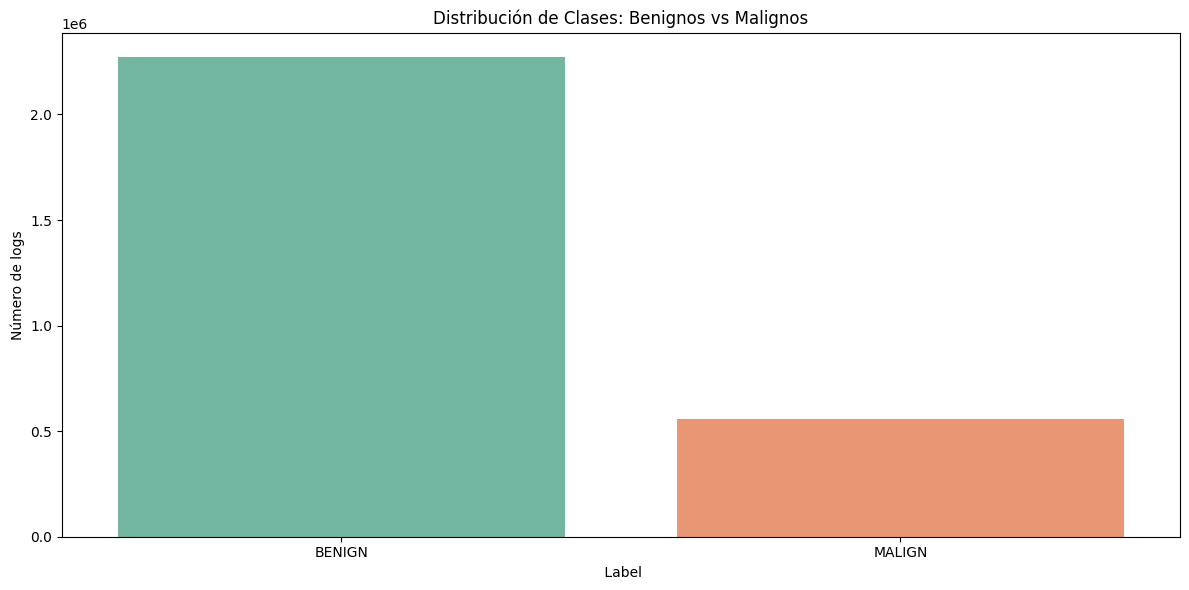

In [5]:
anomalias.plot_class_distribution()

Y como podemos ver, los logs benignos abarcan un 80% de los datos mientras que los malignos un 20%. Esto es importante ya que queremos que la mayoría de datos sean benignos para entrenar el autoencoder, aunque necesitamos una cierta cantidad de logs malignos verificar que la red neuronal (autoencoder) funciona correctamente (esto lo veremos al final de este jupyter)

También es importante conocer los distintos ataques que se han etiquetado a los logs malignos, ya que muchos de estos nos servirán para detectar el tipo de anomalía en nuestro servidor. Principalmente para nuestro servidor web nos fijaremos en DDoS, Brute Force, XSS y SQL Injection (aunque de este último tipo no tenemos muchos datos):

In [6]:
df_malign[' Label'].value_counts()

 Label
DoS Hulk                      231073
PortScan                      158930
DDoS                          128027
DoS GoldenEye                  10293
FTP-Patator                     7938
SSH-Patator                     5897
DoS slowloris                   5796
DoS Slowhttptest                5499
Bot                             1966
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Infiltration                      36
Web Attack � Sql Injection        21
Heartbleed                        11
Name: count, dtype: int64

/home/moyis/Desktop/UAX/Quinto/TFG/AnomaliasTFG/code/anomalias.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_plot, x=' Label', order=df_plot[' Label'].value_counts().index, palette='Set2')


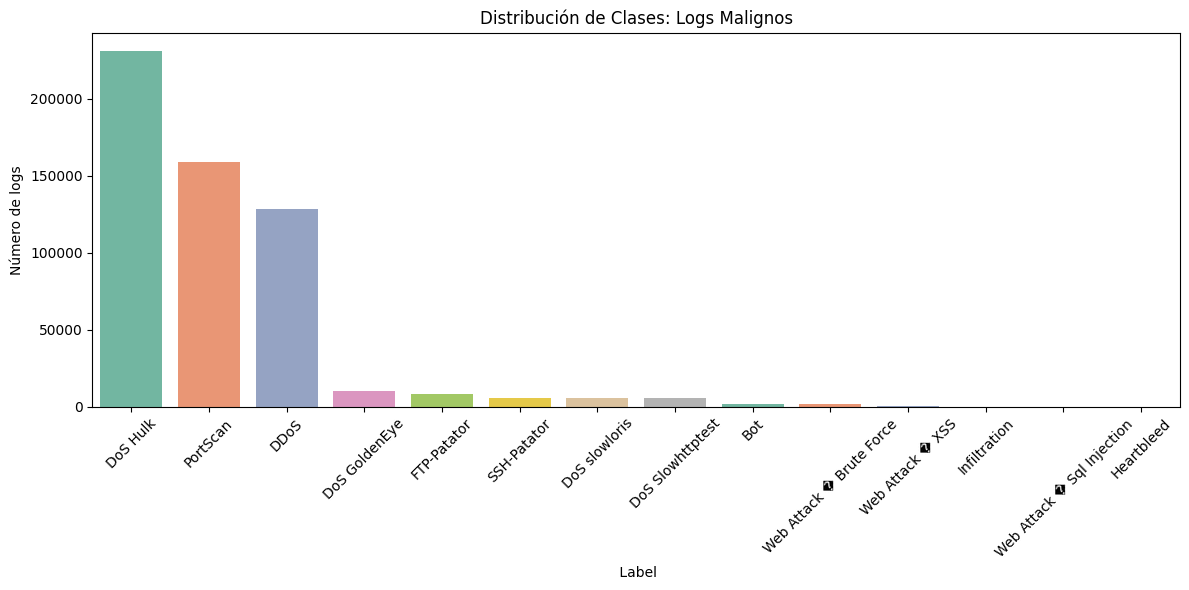

In [7]:
anomalias.plot_class_distribution(malign=True)

Con esto vemos de manera gráfica que los ataques más frecuentes son `DoS Hulk`, `PortScan`, `DDoS`, los cuales muy probablemente, al tener mayor volumen de datos, sean los que el futuro modelo de clasificación predizca mejor. No obstante esto lo haremos más adelante.

/home/moyis/Desktop/UAX/Quinto/TFG/AnomaliasTFG/venv/lib/python3.12/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


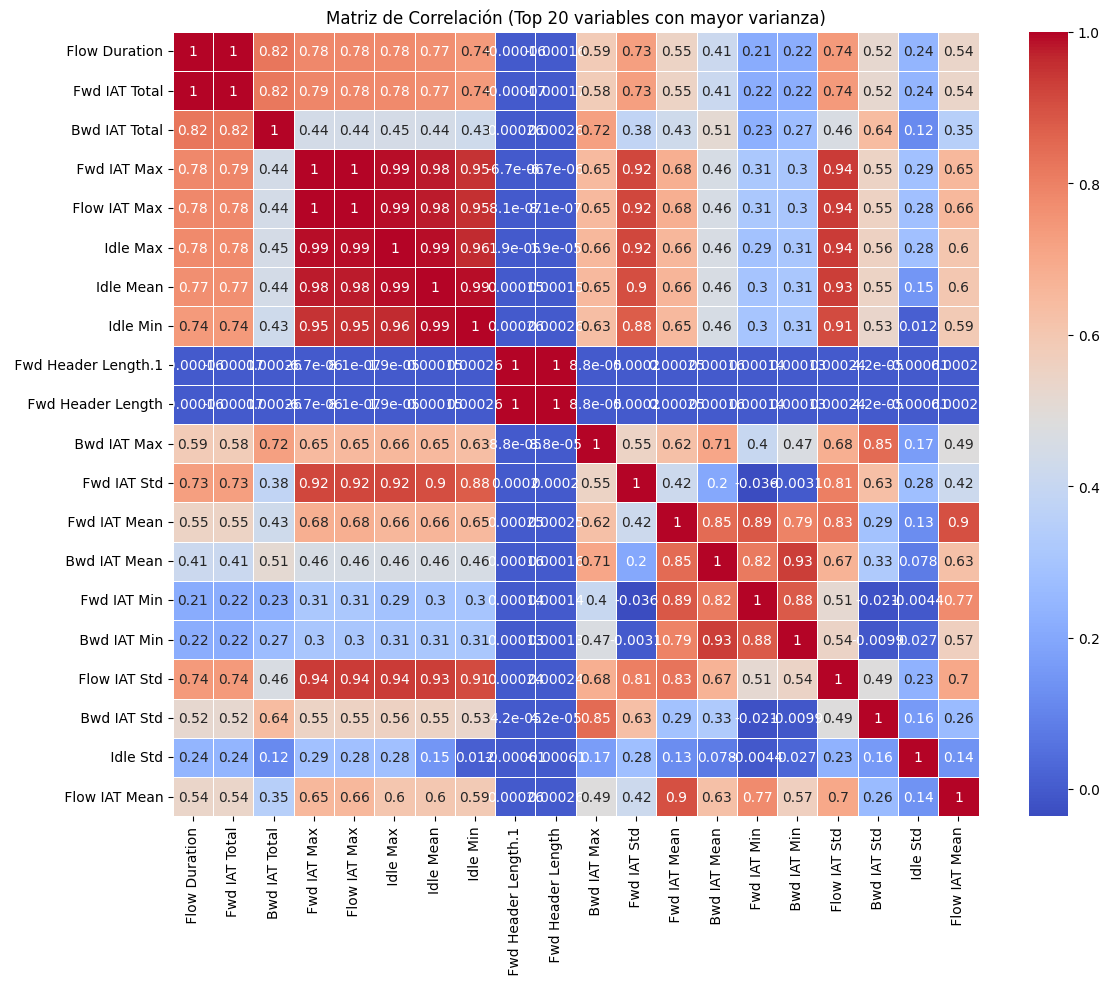

In [8]:
anomalias.plot_correlation_matrix()

## Autoencoder

Una vez hecho esto ya podemos pasar al autoencoder. Para ello tenemos que hacer una pequeña limpieza, ya que encontramos valores de infinito en el dataset los cuales debemos eliminar antes de entrenar el modelo. A su vez tenemos que normalizar dichos datos (escalar sus valores entre 0 y 1) para que el modelo funcione de la mejor manera posible. Esto lo hacemos de la siguiente manera: 

In [10]:
df_benign_cleaned = anomalias.clean_df(df_to_clean=df_benign)
X_train_scaled, X_test_scaled = anomalias.get_scaled_train_test_data(df_benign_cleaned)
print('Tamaño de datos de entrenamiento: ', X_train_scaled.shape)
print('Tamaño de datos de test: ', X_test_scaled.shape)

Tamaño de datos de entrenamiento:  (1817056, 78)
Tamaño de datos de test:  (454264, 78)


A continuación ya nos encontramos en condiciones de entrenar un primer modelo, un modelo muy básico pero que nos va a servir para comprobar que la teoría es cierta:

In [11]:
autoencoder, history = anomalias.create_and_train_autoencoder(X_train_scaled, X_test_scaled)
scaler = anomalias.get_scaler()

Comenzamos el entrenamiento de la red...


2026-03-10 20:18:14.467558: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2026-03-10 20:18:15.429470: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 566921472 exceeds 10% of free system memory.


Epoch 1/5


2026-03-10 20:18:16.766135: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 566921472 exceeds 10% of free system memory.


7098/7098 ━━━━━━━━━━━━━━━━━━━━ 48s 7ms/step - loss: 0.0027 - val_loss: 9.1551e-05
Epoch 2/5
7098/7098 ━━━━━━━━━━━━━━━━━━━━ 42s 6ms/step - loss: 6.7007e-05 - val_loss: 5.1144e-05
Epoch 3/5
7098/7098 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step - loss: 4.4028e-05 - val_loss: 3.5221e-05
Epoch 4/5
7098/7098 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - loss: 3.3538e-05 - val_loss: 3.1959e-05
Epoch 5/5
7098/7098 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - loss: 3.0852e-05 - val_loss: 2.9553e-05


Al pasar los datos de los logs malignos por la red neuronal, deberiamos obtener un error cuadratico medio (mse) mucho mayor, vamos a ver si esto es cierto

Para ello tenemos que hacer un preprocesamiento de igual manera que para X_benign
Eliminamos la columna ' Label', eliminamos valores infinitos y normalizamos los datos

In [12]:
X_malign_cleaned = anomalias.clean_df(df_malign)
X_malign_clean_scaled = scaler.transform(X_malign_cleaned)

Predecimos los resultados con el modelo (autoencoder) definido anteriormente


In [13]:
results_benign = autoencoder.predict(X_test_scaled)
results_malign = autoencoder.predict(X_malign_clean_scaled)

14196/14196 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step
17393/17393 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step


Entonces ya únicamente nos queda calcular el error cuadratico medio para cada caso y comparar los resultados

Segun vimos en la teoria, el error cuadratico medio mse tiene que ser mucho mayor para los logs malignos, ya que la red esta entrenada unicamente con datos benignos, por lo que la tasa de error en este caso se dispararia

In [14]:
mse_benign = np.mean(np.power(X_test_scaled - results_benign, 2))
mse_malign = np.mean(np.power(X_malign_clean_scaled - results_malign, 2))
print('MSE de logs benignos: ', mse_benign)
print('MSE de logs malignos: ', mse_malign)

MSE de logs benignos:  2.955296675039633e-05
MSE de logs malignos:  0.0067875983170893345


Con estos resultados el error de los datos malignos es aproximadamente 100 veces mas grande que los benignos, lo que supone una diferencia significativa y que cumple perfectamente con lo que esperabamos